In [ ]:
import polars as pl
from pathlib import Path

BASE_DIR = Path(r"C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260319_165149_01")
FILE_PATH = BASE_DIR / "master_metrics.parquet"

def run_rrr_analysis():
    df = pl.read_parquet(FILE_PATH)
    
    # 1. Calculate RRR and filter for trading regimes
    df = df.filter(pl.col("total_pos") > 0).with_columns([
        (pl.col("TP") / pl.col("SL")).alias("rrr"),
        (pl.col("win_pos") / pl.col("total_pos")).alias("win_rate")
    ])

    # 2. Group by RRR to see the 'Profitability Heatmap'
    rrr_stats = (
        df.groupby("rrr")
        .agg([
            pl.col("balance").median().alias("med_bal"),
            pl.col("win_rate").mean().alias("avg_win_rate"),
            pl.col("max_drawdown").mean().alias("avg_dd"),
            pl.count().alias("config_count")
        ])
        .sort("med_bal", descending=True)
    )

    print("\n--- RISK-REWARD RATIO PERFORMANCE ---")
    pl.Config.set_tbl_rows(100)
    print(rrr_stats)

    # 3. Correlation: Does high RRR require a specific MA?
    print("\n--- BEST RRR PER MA_INT ---")
    best_per_ma = (
        df.groupby(["ma_int", "rrr"])
        .agg(pl.col("balance").median().alias("med_bal"))
        .sort(["ma_int", "med_bal"], descending=[False, True])
        .groupby("ma_int").head(1)
    )
    print(best_per_ma)

if __name__ == "__main__":
    run_rrr_analysis()


--- RISK-REWARD RATIO PERFORMANCE ---
shape: (59, 5)
┌───────────┬────────────┬──────────────┬──────────┬──────────────┐
│ rrr       ┆ med_bal    ┆ avg_win_rate ┆ avg_dd   ┆ config_count │
│ ---       ┆ ---        ┆ ---          ┆ ---      ┆ ---          │
│ f32       ┆ f32        ┆ f64          ┆ f32      ┆ u32          │
╞═══════════╪════════════╪══════════════╪══════════╪══════════════╡
│ 16.0      ┆ 363.681244 ┆ 0.072916     ┆ 0.403662 ┆ 14367        │
│ 19.0      ┆ 339.051788 ┆ 0.059223     ┆ 0.414486 ┆ 13399        │
│ 12.999999 ┆ 331.56601  ┆ 0.09174      ┆ 0.38535  ┆ 15918        │
│ 22.0      ┆ 273.928558 ┆ 0.049482     ┆ 0.429052 ┆ 12365        │
│ 10.0      ┆ 234.017395 ┆ 0.105783     ┆ 0.35781  ┆ 18765        │
│ 25.0      ┆ 209.938751 ┆ 0.040801     ┆ 0.437229 ┆ 11158        │
│ 7.0       ┆ 201.140594 ┆ 0.145469     ┆ 0.318778 ┆ 21114        │
│ 28.0      ┆ 162.983612 ┆ 0.034706     ┆ 0.437141 ┆ 10292        │
│ 6.5       ┆ 154.399216 ┆ 0.1401       ┆ 0.27249  ┆ 9498     

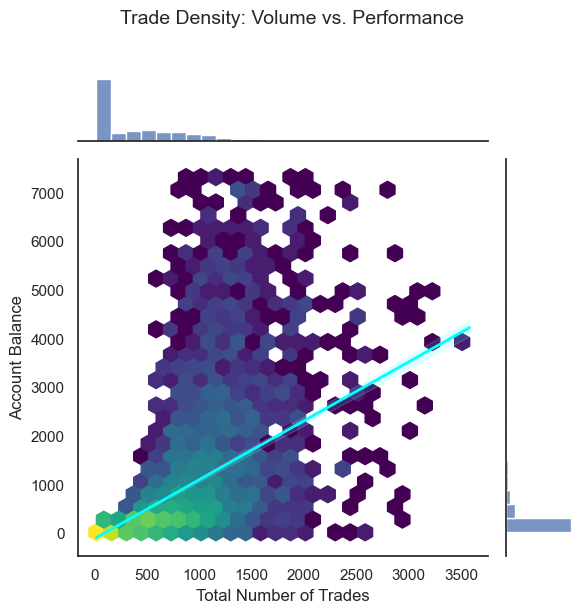

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- CONFIG ---
BASE_DIR = Path(r"C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260319_165149_01")
FILE_PATH = BASE_DIR / "master_metrics.parquet"

def plot_fast_correlation():
    # Load data
    df = pd.read_parquet(FILE_PATH)
    
    # 1. Pre-filter to remove zeros and extreme outliers
    df = df[(df['total_pos'] > 5) & (df['balance'] < df['balance'].quantile(0.98))]
    
    # 2. Aggressive Sampling for Speed
    if len(df) > 15000:
        df = df.sample(15000, random_state=42)

    # Set aesthetic
    sns.set_theme(style="white")
    
    # 3. Hexbin Plot (The heavy lifter)
    g = sns.jointplot(
        data=df, 
        x="total_pos", 
        y="balance", 
        kind="hex", 
        cmap="viridis", # Changed to 'magma' for better visibility on white backgrounds
        gridsize=25,
        bins='log',
        marginal_kws=dict(bins=25, fill=True)
    )

    # 4. Add a regression line (Fixed the 'lw' error here)
    try:
        g.plot_joint(
            sns.regplot, 
            scatter=False, 
            color="cyan", 
            line_kws={'linewidth': 2} # Using line_kws instead of lw
        )
    except Exception as e:
        print(f"Note: Regression line skipped due to: {e}")

    g.fig.suptitle("Trade Density: Volume vs. Performance", y=1.02, fontsize=14)
    g.set_axis_labels("Total Number of Trades", "Account Balance")
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_fast_correlation()

In [23]:
import polars as pl
from pathlib import Path

# --- CONFIG ---
BASE_DIR = Path(r"C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260319_165149_01")
FILE_PATH = BASE_DIR / "master_metrics.parquet"

def run_frequency_table():
    df = pl.read_parquet(FILE_PATH)

    # 1. Create 'Trade Buckets' (Binning the X-axis of your graph)
    # This groups trades into blocks of 500
    df = df.with_columns([
        ((pl.col("total_pos") // 500) * 500).alias("trade_bucket")
    ])

    # 2. Aggregate metrics per bucket
    # This is the tabular version of your Hexbin density
    stats_table = (
        df.groupby("trade_bucket")
        .agg([
            pl.count().alias("config_count"),
            pl.col("balance").median().alias("med_bal"),
            pl.col("balance").max().alias("max_bal"),
            pl.col("max_drawdown").median().alias("med_dd"),
            pl.col("max_drawdown").max().alias("worst_dd"),
            (pl.col("win_pos").sum() / pl.col("total_pos").sum()).alias("avg_win_rate")
        ])
        .sort("trade_bucket")
    )

    print("\n--- PERFORMANCE BY TRADE FREQUENCY (BUCKETS OF 500) ---")
    pl.Config.set_tbl_rows(100)
    print(stats_table)

    # 3. Find the "Efficiency" (Profit per Trade)
    # This is the tabular version of your 'Linear Slope'
    efficiency = stats_table.with_columns([
        ((pl.col("med_bal") - 100) / (pl.col("trade_bucket") + 250)).alias("profit_per_trade")
    ]).select(["trade_bucket", "profit_per_trade"])

    print("\n--- STRATEGY EFFICIENCY (PROFIT PER UNIT OF TRADE) ---")
    print(efficiency)

if __name__ == "__main__":
    run_frequency_table()


--- PERFORMANCE BY TRADE FREQUENCY (BUCKETS OF 500) ---
shape: (17, 7)
┌──────────────┬──────────────┬──────────────┬──────────────┬──────────┬──────────┬──────────────┐
│ trade_bucket ┆ config_count ┆ med_bal      ┆ max_bal      ┆ med_dd   ┆ worst_dd ┆ avg_win_rate │
│ ---          ┆ ---          ┆ ---          ┆ ---          ┆ ---      ┆ ---      ┆ ---          │
│ i32          ┆ u32          ┆ f32          ┆ f32          ┆ f32      ┆ f32      ┆ f64          │
╞══════════════╪══════════════╪══════════════╪══════════════╪══════════╪══════════╪══════════════╡
│ 0            ┆ 479319       ┆ 100.0        ┆ 1848.279053  ┆ 0.0      ┆ 0.690751 ┆ 0.083049     │
│ 500          ┆ 66340        ┆ 324.616455   ┆ 29164.191406 ┆ 0.375334 ┆ 0.716726 ┆ 0.109079     │
│ 1000         ┆ 27876        ┆ 1097.6521    ┆ 1.1550e6     ┆ 0.462108 ┆ 0.744389 ┆ 0.106602     │
│ 1500         ┆ 8642         ┆ 4000.773926  ┆ 4.6201164e7  ┆ 0.534212 ┆ 0.739709 ┆ 0.108242     │
│ 2000         ┆ 2382         ┆ 12267

In [27]:
import polars as pl
from pathlib import Path

# --- CONFIG ---
BASE_DIR = Path(r"C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260319_165149_01")
FILE_PATH = BASE_DIR / "master_metrics.parquet"

def find_middle_ground():
    df = pl.read_parquet(FILE_PATH)

    # 1. Filter for the "Professional Risk Zone" (DD <= 0.10)
    # We also want configs that actually trade (total_pos > 50)
    safe_active = df.filter(
        (pl.col("max_drawdown") <= 0.05) & 
        (pl.col("total_pos") > 50)
    )

    if safe_active.is_empty():
        print("No configs found under 10% DD. Try 15%.")
        return

    # 2. Add Win Rate and Power Score
    safe_active = safe_active.with_columns([
        (pl.col("win_pos") / pl.col("total_pos")).alias("win_rate"),
        # We rank by Balance * Trades to find the 'Hardest Workers'
        (pl.col("balance") * pl.col("total_pos")).alias("activity_score")
    ])

    # 3. Sort by Balance & Activity
    middle_ground = (
        safe_active.sort("balance", descending=True)
        .select([
            "ma_int", "entry_lookback_units", "stoch_key", 
            "total_pos", "balance", "win_rate", "max_drawdown"
        ])
        .head(30)
    )

    print("\n--- THE MIDDLE GROUND (Safe + High Activity) ---")
    print(middle_ground)

if __name__ == "__main__":
    find_middle_ground()


--- THE MIDDLE GROUND (Safe + High Activity) ---
shape: (30, 7)
┌────────┬──────────────────────┬─────────────┬───────────┬────────────┬──────────┬──────────────┐
│ ma_int ┆ entry_lookback_units ┆ stoch_key   ┆ total_pos ┆ balance    ┆ win_rate ┆ max_drawdown │
│ ---    ┆ ---                  ┆ ---         ┆ ---       ┆ ---        ┆ ---      ┆ ---          │
│ i32    ┆ i32                  ┆ str         ┆ i32       ┆ f32        ┆ f64      ┆ f32          │
╞════════╪══════════════════════╪═════════════╪═══════════╪════════════╪══════════╪══════════════╡
│ 1      ┆ 6                    ┆ k14_l30_u70 ┆ 57        ┆ 177.73587  ┆ 0.280702 ┆ 0.04411      │
│ 1      ┆ 6                    ┆ k14_l30_u70 ┆ 57        ┆ 177.73587  ┆ 0.280702 ┆ 0.04411      │
│ 1      ┆ 6                    ┆ k14_l30_u70 ┆ 57        ┆ 177.73587  ┆ 0.280702 ┆ 0.04411      │
│ 1      ┆ 6                    ┆ k14_l30_u70 ┆ 57        ┆ 177.73587  ┆ 0.280702 ┆ 0.04411      │
│ 0      ┆ 5                    ┆ k12_l30_u7

In [36]:
import polars as pl
from pathlib import Path

# --- CONFIG ---
BASE_DIR = Path(r"C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260319_165149_01")
FILE_PATH = BASE_DIR / "master_metrics.parquet"

def compare_siblings_fixed():
    # 1. Load data
    df = pl.read_parquet(FILE_PATH)
    
    # 2. Split data into two groups: The "Filtered" and the "OFF"
    # Filtered Group: Top 15 by balance where DD <= 0.05
    safe_kings = (
        df.filter((pl.col("max_drawdown") <= 0.05) & (pl.col("stoch_key") != "OFF"))
        .sort("balance", descending=True)
        .head(15)
    )
    
    # OFF Group: All rows where stoch is OFF
    off_group = df.filter(pl.col("stoch_key") == "OFF")
    
    # 3. Join them together on MA and Lookback
    # This automatically aligns the 'Safe' row with its 'OFF' sibling
    comparison = safe_kings.join(
        off_group, 
        on=["ma_int", "entry_lookback_units"], 
        suffix="_OFF"
    )
    
    # 4. Clean up the columns for a clear report
    report = comparison.select([
        pl.col("ma_int").alias("MA"),
        pl.col("entry_lookback_units").alias("Look"),
        pl.col("stoch_key").alias("STOCH"),
        pl.col("balance").round(2).alias("S_BAL"),
        pl.col("balance_OFF").round(2).alias("OFF_BAL"),
        pl.col("max_drawdown").round(4).alias("S_DD"),
        pl.col("max_drawdown_OFF").round(4).alias("OFF_DD"),
        (pl.col("max_drawdown_OFF") - pl.col("max_drawdown")).round(4).alias("DD_IMP")
    ]).unique()

    print("\n--- SIDE-BY-SIDE: STOCHASTIC ON VS. OFF (JOIN METHOD) ---")
    if report.is_empty():
        print("No matching siblings found. Double check if 'OFF' is exactly 'OFF' in your data.")
    else:
        print(report.sort("S_BAL", descending=True))

if __name__ == "__main__":
    compare_siblings_fixed()


--- SIDE-BY-SIDE: STOCHASTIC ON VS. OFF (JOIN METHOD) ---
shape: (496, 8)
┌─────┬──────┬─────────────┬────────────┬───────────────┬────────┬────────┬────────┐
│ MA  ┆ Look ┆ STOCH       ┆ S_BAL      ┆ OFF_BAL       ┆ S_DD   ┆ OFF_DD ┆ DD_IMP │
│ --- ┆ ---  ┆ ---         ┆ ---        ┆ ---           ┆ ---    ┆ ---    ┆ ---    │
│ i32 ┆ i32  ┆ str         ┆ f32        ┆ f32           ┆ f32    ┆ f32    ┆ f32    │
╞═════╪══════╪═════════════╪════════════╪═══════════════╪════════╪════════╪════════╡
│ 1   ┆ 6    ┆ k14_l30_u70 ┆ 177.740005 ┆ 32.77         ┆ 0.0441 ┆ 0.6723 ┆ 0.6282 │
│ 1   ┆ 6    ┆ k14_l30_u70 ┆ 177.740005 ┆ 33.849998     ┆ 0.0441 ┆ 0.6615 ┆ 0.6174 │
│ 1   ┆ 6    ┆ k14_l30_u70 ┆ 177.740005 ┆ 8204.009766   ┆ 0.0441 ┆ 0.6086 ┆ 0.5645 │
│ 1   ┆ 6    ┆ k14_l30_u70 ┆ 177.740005 ┆ 1168.140015   ┆ 0.0441 ┆ 0.6557 ┆ 0.6115 │
│ 1   ┆ 6    ┆ k14_l30_u70 ┆ 177.740005 ┆ 4313.22998    ┆ 0.0441 ┆ 0.5299 ┆ 0.4858 │
│ 1   ┆ 6    ┆ k14_l30_u70 ┆ 177.740005 ┆ 8750.349609   ┆ 0.0441 ┆ 0.5233 ┆

In [37]:
import polars as pl
from pathlib import Path

# --- CONFIG ---
BASE_DIR = Path(r"C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260319_165149_01")
FILE_PATH = BASE_DIR / "master_metrics.parquet"

def find_robust_configs():
    df = pl.read_parquet(FILE_PATH)
    
    # 1. Filter for your 5% DD limit
    # 2. ALSO Filter for a minimum trade count (at least 120 trades over 2 years)
    robust_df = df.filter(
        (pl.col("max_drawdown") <= 0.05) & 
        (pl.col("total_pos") >= 120)
    )

    if robust_df.is_empty():
        print("⚠️ No configs found with >120 trades and <5% DD. Your 5% limit might be too strict for high-frequency trading.")
        # Fallback: Let's see what the most active config under 5% DD actually is
        robust_df = df.filter(pl.col("max_drawdown") <= 0.05).sort("total_pos", descending=True).head(10)
    
    # 3. Rank by a 'Stability Score' (Trades * WinRate)
    report = robust_df.with_columns([
        (pl.col("total_pos") * (pl.col("win_pos") / pl.col("total_pos"))).alias("stability")
    ]).sort("total_pos", descending=True)

    print("\n--- MOST ROBUST CONFIGS (High Trades + Low DD) ---")
    print(report.select([
        "ma_int", "entry_lookback_units", "stoch_key", "total_pos", "balance", "max_drawdown"
    ]).head(15))

if __name__ == "__main__":
    find_robust_configs()

⚠️ No configs found with >120 trades and <5% DD. Your 5% limit might be too strict for high-frequency trading.

--- MOST ROBUST CONFIGS (High Trades + Low DD) ---
shape: (10, 6)
┌────────┬──────────────────────┬─────────────┬───────────┬────────────┬──────────────┐
│ ma_int ┆ entry_lookback_units ┆ stoch_key   ┆ total_pos ┆ balance    ┆ max_drawdown │
│ ---    ┆ ---                  ┆ ---         ┆ ---       ┆ ---        ┆ ---          │
│ i32    ┆ i32                  ┆ str         ┆ i32       ┆ f32        ┆ f32          │
╞════════╪══════════════════════╪═════════════╪═══════════╪════════════╪══════════════╡
│ 0      ┆ 5                    ┆ k14_l30_u70 ┆ 86        ┆ 163.983414 ┆ 0.04889      │
│ 0      ┆ 5                    ┆ k14_l30_u70 ┆ 86        ┆ 163.983414 ┆ 0.04889      │
│ 0      ┆ 5                    ┆ k14_l30_u70 ┆ 86        ┆ 163.983414 ┆ 0.04889      │
│ 0      ┆ 5                    ┆ k14_l30_u70 ┆ 86        ┆ 163.983414 ┆ 0.04889      │
│ 3      ┆ 4                  

In [38]:
import polars as pl
from pathlib import Path

# --- CONFIG ---
BASE_DIR = Path(r"C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260319_165149_01")
FILE_PATH = BASE_DIR / "master_metrics.parquet"

def test_stoch_by_lookback():
    df = pl.read_parquet(FILE_PATH)

    # 1. Create a simple "Stoch Status" column
    df = df.with_columns([
        pl.when(pl.col("stoch_key") == "OFF")
        .then(pl.lit("OFF"))
        .otherwise(pl.lit("ON"))
        .alias("stoch_status"),
        (pl.col("win_pos") / pl.col("total_pos")).alias("win_rate")
    ])

    # 2. Group by Lookback and Status
    # We use MEDIAN because the OFF versions have crazy "Billions" outliers
    summary = (
        df.groupby(["entry_lookback_units", "stoch_status"])
        .agg([
            pl.col("balance").median().alias("med_bal"),
            pl.col("max_drawdown").median().alias("med_dd"),
            pl.col("win_rate").median().alias("med_win_rate"),
            pl.col("total_pos").median().alias("med_trades"),
            pl.count().alias("config_count")
        ])
        .sort(["entry_lookback_units", "stoch_status"])
    )

    print("\n--- PERFORMANCE BY LOOKBACK & STOCHASTIC STATUS ---")
    print(summary)

    # 3. Calculate "Efficiency" (Return per unit of Risk)
    # This proves consistency regardless of trade count
    efficiency = summary.with_columns([
        (pl.col("med_bal") / pl.col("med_dd")).alias("stability_score")
    ]).select(["entry_lookback_units", "stoch_status", "stability_score"])

    print("\n--- STABILITY SCORE (Higher is better) ---")
    print(efficiency)

if __name__ == "__main__":
    test_stoch_by_lookback()


--- PERFORMANCE BY LOOKBACK & STOCHASTIC STATUS ---
shape: (12, 7)
┌──────────────┬──────────────┬──────────────┬──────────┬──────────────┬────────────┬──────────────┐
│ entry_lookba ┆ stoch_status ┆ med_bal      ┆ med_dd   ┆ med_win_rate ┆ med_trades ┆ config_count │
│ ck_units     ┆ ---          ┆ ---          ┆ ---      ┆ ---          ┆ ---        ┆ ---          │
│ ---          ┆ str          ┆ f32          ┆ f32      ┆ f64          ┆ f64        ┆ u32          │
│ i32          ┆              ┆              ┆          ┆              ┆            ┆              │
╞══════════════╪══════════════╪══════════════╪══════════╪══════════════╪════════════╪══════════════╡
│ 0            ┆ OFF          ┆ 100.0        ┆ 0.0      ┆ NaN          ┆ 0.0        ┆ 30360        │
│ 0            ┆ ON           ┆ 100.0        ┆ 0.0      ┆ NaN          ┆ 0.0        ┆ 284480       │
│ 1            ┆ OFF          ┆ 1590.010864  ┆ 0.564858 ┆ 0.15895      ┆ 883.0      ┆ 312          │
│ 1            ┆ ON    

In [51]:
import polars as pl
from pathlib import Path

# --- CONFIG ---
BASE_DIR = Path(r"C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260319_165149_01")
FILE_PATH = BASE_DIR / "master_metrics.parquet"

def find_safe_stoch_alpha():
    # Force wide display so we see everything
    pl.Config.set_tbl_cols(10)
    
    df = pl.read_parquet(FILE_PATH)

    # 1. THE "SAFE ZONE" FILTER (Under 5% Drawdown)
    # Using explicit OR (|) to avoid the is_in() bug
    safe_df = df.filter(
        (pl.col("max_drawdown") <= 0.05) &
        ((pl.col("entry_lookback_units") == 5) | (pl.col("entry_lookback_units") == 6)) & 
        (pl.col("stoch_key") != "OFF") &
        (pl.col("total_pos") > 20) 
    ).with_columns([
        (pl.col("win_pos") / pl.col("total_pos")).alias("win_rate")
    ])

    if safe_df.is_empty():
        print("⚠️ No configurations found with DD < 5% for Lookbacks 5/6.")
        print("This means NO combination of MA/SL/TP stayed under 5% with these lookbacks.")
        return

    # 2. Group by Stoch Setting
    # 'count' tells us which setting is the most "Reliable" across different MA/SL/TPs
    stoch_safe_ranking = (
        safe_df.groupby("stoch_key")
        .agg([
            pl.col("win_rate").mean().alias("avg_win_rate"),
            pl.col("balance").median().alias("med_bal"),
            pl.col("max_drawdown").mean().alias("avg_dd"),
            pl.col("total_pos").mean().alias("avg_trades"),
            pl.count().alias("safe_variants") 
        ])
        .sort("safe_variants", descending=True)
    )

    print("\n--- THE 'SURVIVORS': STOCH SETTINGS THAT STAYED UNDER 5% DD ---")
    print(stoch_safe_ranking)

if __name__ == "__main__":
    find_safe_stoch_alpha()


--- THE 'SURVIVORS': STOCH SETTINGS THAT STAYED UNDER 5% DD ---
shape: (5, 6)
┌─────────────┬──────────────┬────────────┬──────────┬────────────┬───────────────┐
│ stoch_key   ┆ avg_win_rate ┆ med_bal    ┆ avg_dd   ┆ avg_trades ┆ safe_variants │
│ ---         ┆ ---          ┆ ---        ┆ ---      ┆ ---        ┆ ---           │
│ str         ┆ f64          ┆ f32        ┆ f32      ┆ f64        ┆ u32           │
╞═════════════╪══════════════╪════════════╪══════════╪════════════╪═══════════════╡
│ k12_l30_u70 ┆ 0.248658     ┆ 115.510468 ┆ 0.044382 ┆ 38.602151  ┆ 372           │
│ k10_l30_u70 ┆ 0.284653     ┆ 116.834404 ┆ 0.042639 ┆ 31.407895  ┆ 304           │
│ k14_l30_u70 ┆ 0.279429     ┆ 125.567841 ┆ 0.045056 ┆ 44.227723  ┆ 202           │
│ k12_l40_u60 ┆ 0.296202     ┆ 130.481583 ┆ 0.047203 ┆ 64.764706  ┆ 34            │
│ k10_l40_u60 ┆ 0.318927     ┆ 128.356216 ┆ 0.047152 ┆ 61.0       ┆ 11            │
└─────────────┴──────────────┴────────────┴──────────┴────────────┴──────────────

In [53]:
import polars as pl
from pathlib import Path

# --- CONFIG ---
BASE_DIR = Path(r"C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260319_165149_01")
FILE_PATH = BASE_DIR / "master_metrics.parquet"

def check_era_robustness():
    df = pl.read_parquet(FILE_PATH)

    # 1. Filter for the Safe Zone (< 5% DD)
    # Target only Lookbacks 5 and 6
    safe_df = df.filter(
        (pl.col("max_drawdown") <= 0.05) &
        ((pl.col("entry_lookback_units") == 5) | (pl.col("entry_lookback_units") == 6)) &
        (pl.col("stoch_key") != "OFF")
    )

    # 2. Group by Stoch Key and see which Eras they appeared in
    era_stats = (
        safe_df.groupby("stoch_key")
        .agg([
            pl.col("era_int").n_unique().alias("eras_survived"),
            pl.col("era_int").unique().alias("specific_eras"),
            pl.col("balance").median().alias("med_bal"),
            pl.count().alias("total_safe_configs")
        ])
        .sort("eras_survived", descending=True)
    )

    print("\n--- ERA SURVIVAL (ROBUSTNESS TEST) ---")
    print(era_stats)

    # 3. Deep Dive into the 'All-Era' Survivors
    all_era_survivors = era_stats.filter(pl.col("eras_survived") == 4)
    
    if all_era_survivors.is_empty():
        print("\n⚠️ No single Stoch setting survived ALL 4 eras under 5% DD.")
        print("Check for settings with 3 eras survived.")
    else:
        print("\n🏆 THE ROBUST KINGS (Survived all 4 Eras):")
        print(all_era_survivors.select(["stoch_key", "med_bal", "total_safe_configs"]))

if __name__ == "__main__":
    check_era_robustness()


--- ERA SURVIVAL (ROBUSTNESS TEST) ---
shape: (5, 5)
┌─────────────┬───────────────┬───────────────┬────────────┬────────────────────┐
│ stoch_key   ┆ eras_survived ┆ specific_eras ┆ med_bal    ┆ total_safe_configs │
│ ---         ┆ ---           ┆ ---           ┆ ---        ┆ ---                │
│ str         ┆ u32           ┆ list[i64]     ┆ f32        ┆ u32                │
╞═════════════╪═══════════════╪═══════════════╪════════════╪════════════════════╡
│ k12_l30_u70 ┆ 1             ┆ [20250901]    ┆ 115.510468 ┆ 372                │
│ k10_l30_u70 ┆ 1             ┆ [20250901]    ┆ 114.252892 ┆ 360                │
│ k10_l40_u60 ┆ 1             ┆ [20250901]    ┆ 128.356216 ┆ 11                 │
│ k14_l30_u70 ┆ 1             ┆ [20250901]    ┆ 125.567841 ┆ 202                │
│ k12_l40_u60 ┆ 1             ┆ [20250901]    ┆ 130.481583 ┆ 34                 │
└─────────────┴───────────────┴───────────────┴────────────┴────────────────────┘

⚠️ No single Stoch setting survived ALL 4 e

In [57]:
import polars as pl
from pathlib import Path

# --- CONFIG ---
BASE_DIR = Path(r"C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260319_165149_01")
FILE_PATH = BASE_DIR / "master_metrics.parquet"

def analyze_specific_era():
    df = pl.read_parquet(FILE_PATH)

    # 1. Filter for the specific era and Lookbacks 5/6
    # We create the win_rate column immediately after filtering
    era_df = df.filter(
        (pl.col("era_int") == 20250301) &
        ((pl.col("entry_lookback_units") == 5) | (pl.col("entry_lookback_units") == 6)) &
        (pl.col("stoch_key") != "OFF") &
        (pl.col("total_pos") > 0)
    ).with_columns([
        (pl.col("win_pos") / pl.col("total_pos")).alias("win_rate")
    ])

    if era_df.is_empty():
        print("⚠️ No data found for era 20250301.")
        return

    # 2. Find the "Natural Floor" for Drawdown
    # This shows the absolute best safety achieved in this era
    min_dd = era_df.select(pl.col("max_drawdown").min()).item()
    p5_dd = era_df.select(pl.col("max_drawdown").quantile(0.05)).item()
    
    print(f"\n--- ERA 2025-03-01 ANALYSIS ---")
    print(f"Absolute Minimum DD found: {min_dd:.2%}")
    print(f"The 'Safest' 5% of configs had a DD under: {p5_dd:.2%}")

    # 3. Group by Stoch setting to see what survived best
    # Using a 10% limit to catch the 'near-misses' for your 5% target
    safe_era_ranking = (
        era_df.filter(pl.col("max_drawdown") <= 0.10)
        .groupby("stoch_key")
        .agg([
            pl.col("win_rate").mean().alias("avg_win_rate"),
            pl.col("max_drawdown").min().alias("best_dd"),
            pl.col("max_drawdown").mean().alias("avg_dd"),
            pl.col("total_pos").mean().alias("avg_trades"),
            pl.count().alias("safe_variants_under_10pct")
        ])
        .sort("safe_variants_under_10pct", descending=True)
    )

    print("\n--- TOP STOCH SETTINGS FOR ERA 2025-03-01 (DD <= 10%) ---")
    if safe_era_ranking.is_empty():
        print("No settings stayed under 10% DD in this era.")
    else:
        print(safe_era_ranking.head(15))

if __name__ == "__main__":
    analyze_specific_era()


--- ERA 2025-03-01 ANALYSIS ---
Absolute Minimum DD found: 11.18%
The 'Safest' 5% of configs had a DD under: 20.72%

--- TOP STOCH SETTINGS FOR ERA 2025-03-01 (DD <= 10%) ---
No settings stayed under 10% DD in this era.


In [59]:
import polars as pl
from pathlib import Path

FILE_PATH = Path(r"C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260319_165149_01\master_metrics.parquet")

def check_data_distribution():
    df = pl.read_parquet(FILE_PATH)
    
    # Count how many test results exist for each Era
    era_counts = (
        df.groupby("era_int")
        .agg(pl.count().alias("test_configs"))
        .sort("era_int")
    )
    
    print("\n--- DATA DISTRIBUTION BY ERA ---")
    print(era_counts)

if __name__ == "__main__":
    check_data_distribution()


--- DATA DISTRIBUTION BY ERA ---
shape: (5, 2)
┌──────────┬──────────────┐
│ era_int  ┆ test_configs │
│ ---      ┆ ---          │
│ i64      ┆ u32          │
╞══════════╪══════════════╡
│ 20230901 ┆ 92608        │
│ 20240301 ┆ 110009       │
│ 20240901 ┆ 102044       │
│ 20250301 ┆ 87460        │
│ 20250901 ┆ 196924       │
└──────────┴──────────────┘


In [61]:
import polars as pl
from pathlib import Path

FILE_PATH = Path(r"C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260319_165149_01\master_metrics.parquet")

def compare_disaster_mitigation():
    df = pl.read_parquet(FILE_PATH)

    # 1. Focus ONLY on the hard era (March 2025)
    # 2. Add the Win Rate calculation
    hard_era = df.filter(pl.col("era_int") == 20250301).with_columns([
        (pl.col("win_pos") / pl.col("total_pos")).alias("win_rate"),
        pl.when(pl.col("stoch_key") == "OFF").then(pl.lit("OFF")).otherwise(pl.lit("ON")).alias("stoch_status")
    ])

    # 3. Compare Median Performance
    comparison = (
        hard_era.groupby("stoch_status")
        .agg([
            pl.col("max_drawdown").median().alias("med_dd"),
            pl.col("max_drawdown").min().alias("best_case_dd"),
            pl.col("win_rate").median().alias("med_win_rate"),
            pl.col("balance").median().alias("med_bal"),
            pl.count().alias("configs")
        ])
    )

    print("\n--- STOCHASTIC VS. NO-STOCH (MARCH 2025 DISASTER TEST) ---")
    print(comparison)

if __name__ == "__main__":
    compare_disaster_mitigation()


--- STOCHASTIC VS. NO-STOCH (MARCH 2025 DISASTER TEST) ---
shape: (2, 6)
┌──────────────┬────────┬──────────────┬──────────────┬─────────┬─────────┐
│ stoch_status ┆ med_dd ┆ best_case_dd ┆ med_win_rate ┆ med_bal ┆ configs │
│ ---          ┆ ---    ┆ ---          ┆ ---          ┆ ---     ┆ ---     │
│ str          ┆ f32    ┆ f32          ┆ f64          ┆ f32     ┆ u32     │
╞══════════════╪════════╪══════════════╪══════════════╪═════════╪═════════╡
│ ON           ┆ 0.0    ┆ 0.0          ┆ NaN          ┆ 100.0   ┆ 80850   │
│ OFF          ┆ 0.0    ┆ 0.0          ┆ NaN          ┆ 100.0   ┆ 6610    │
└──────────────┴────────┴──────────────┴──────────────┴─────────┴─────────┘


In [63]:
import polars as pl
from pathlib import Path

FILE_PATH = Path(r"C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260319_165149_01\master_metrics.parquet")

def check_activity_by_era():
    df = pl.read_parquet(FILE_PATH)

    # Group by Era and Stoch setting to see how many TRADES actually happened
    activity = (
        df.groupby(["era_int", "stoch_key"])
        .agg([
            pl.col("total_pos").mean().alias("avg_trades_placed"),
            pl.col("max_drawdown").median().alias("med_dd")
        ])
        .filter(pl.col("stoch_key") != "OFF")
        .sort(["era_int", "avg_trades_placed"], descending=[False, True])
    )

    print("\n--- TRADE ACTIVITY PER ERA (STOCH ON) ---")
    # Let's look at the top 3 most active Stoch settings for EACH era
    for era in activity["era_int"].unique().sort():
        print(f"\nEra: {era}")
        print(activity.filter(pl.col("era_int") == era).head(3))

if __name__ == "__main__":
    check_activity_by_era()


--- TRADE ACTIVITY PER ERA (STOCH ON) ---

Era: 20230901
shape: (3, 4)
┌──────────┬─────────────┬───────────────────┬────────┐
│ era_int  ┆ stoch_key   ┆ avg_trades_placed ┆ med_dd │
│ ---      ┆ ---         ┆ ---               ┆ ---    │
│ i64      ┆ str         ┆ f64               ┆ f32    │
╞══════════╪═════════════╪═══════════════════╪════════╡
│ 20230901 ┆ k10_l50_u50 ┆ 346.48335         ┆ 0.0    │
│ 20230901 ┆ k12_l50_u50 ┆ 339.738272        ┆ 0.0    │
│ 20230901 ┆ k14_l50_u50 ┆ 335.774194        ┆ 0.0    │
└──────────┴─────────────┴───────────────────┴────────┘

Era: 20240301
shape: (3, 4)
┌──────────┬─────────────┬───────────────────┬────────┐
│ era_int  ┆ stoch_key   ┆ avg_trades_placed ┆ med_dd │
│ ---      ┆ ---         ┆ ---               ┆ ---    │
│ i64      ┆ str         ┆ f64               ┆ f32    │
╞══════════╪═════════════╪═══════════════════╪════════╡
│ 20240301 ┆ k10_l50_u50 ┆ 448.916864        ┆ 0.0    │
│ 20240301 ┆ k14_l50_u50 ┆ 443.693582        ┆ 0.0    │
│ 2

In [65]:
import pyarrow.parquet as pq

file_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260320_110540_01\results\batch_0001_master_metrics.parquet'

# Read only the footer/metadata
metadata = pq.read_metadata(file_path)

print(f"Total Rows: {metadata.num_rows}")
print(f"Total Columns: {metadata.num_columns}")
print(f"Number of Row Groups: {metadata.num_row_groups}")

if metadata.num_rows == 0:
    print("⚠️ The file is empty (contains 0 rows).")

Total Rows: 0
Total Columns: 18
Number of Row Groups: 0
⚠️ The file is empty (contains 0 rows).


In [2]:
import pyarrow.parquet as pq

# Define your file path
file_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260320_184921_01\master_metrics.parquet'

# 1. Read only the metadata (No row data is loaded into RAM)
metadata = pq.read_metadata(file_path)

# 2. Get the Row Count
row_count = metadata.num_rows

# 3. Get the Schema
schema = metadata.schema.to_arrow_schema()

print(f"Total Rows: {row_count}")
print("-" * 20)
print("Schema:")
print(schema)

Total Rows: 40332
--------------------
Schema:
regime_id: int32
era_int: int64
side: int8
ma_int: int32
ma_reversion: bool
entry_lookback_units: int32
exit_window_h: int32
use_stochastic: bool
stoch_key: large_string
use_bbw: bool
bbw_periods: int32
bbw_std: float
SL: float
TP: float
total_pos: int32
win_pos: int32
balance: float
max_drawdown: float


In [7]:
import polars as pl
pl.Config.set_tbl_cols(-1)       # -1 means "show all columns"
pl.Config.set_tbl_width_chars(1000) # Increase the character limit for the whole table
pl.Config.set_tbl_rows(50)

def rank_best_configs(parquet_path: str, top_n: int = 20):
    # 1. Scan the master metrics
    df = pl.scan_parquet(parquet_path)

    # 2. Define the 'Grouping Keys'
    grouping_keys = [
        "regime_id", "side", "ma_int", "ma_reversion", "entry_lookback_units",
        "exit_window_h", "use_stochastic", "stoch_key", "use_bbw", 
        "bbw_periods", "bbw_std", "SL", "TP"
    ]

    # 3. Aggregate performance
    # Fixed: Replaced pl.len() with pl.count() for older Polars versions
    ranked_df = (
        df
        .groupby(grouping_keys)
        .agg([
            pl.col("balance").mean().alias("avg_balance"),
            pl.col("balance").median().alias("med_balance"),
            pl.col("max_drawdown").mean().alias("avg_dd"),
            pl.col("total_pos").sum().alias("total_trades"),
            pl.col("win_pos").sum().alias("total_wins"),
            pl.count().alias("era_count")  # Works in older versions
        ])
        # 4. Filter and Sort
        .filter(pl.col("era_count") > 1)
        .sort("avg_balance", descending=True)
        .limit(top_n)
        .collect()
    )

    return ranked_df

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260320_184921_01\master_metrics.parquet'
best_configs = rank_best_configs(results_path)

print("🏆 TOP CONFIGS BY AVERAGE BALANCE:")
print(best_configs)

🏆 TOP CONFIGS BY AVERAGE BALANCE:
shape: (20, 19)
┌───────────┬──────┬────────┬──────────────┬──────────────────────┬───────────────┬────────────────┬─────────────┬─────────┬─────────────┬─────────┬─────┬─────┬─────────────┬─────────────┬──────────┬──────────────┬────────────┬───────────┐
│ regime_id ┆ side ┆ ma_int ┆ ma_reversion ┆ entry_lookback_units ┆ exit_window_h ┆ use_stochastic ┆ stoch_key   ┆ use_bbw ┆ bbw_periods ┆ bbw_std ┆ SL  ┆ TP  ┆ avg_balance ┆ med_balance ┆ avg_dd   ┆ total_trades ┆ total_wins ┆ era_count │
│ ---       ┆ ---  ┆ ---    ┆ ---          ┆ ---                  ┆ ---           ┆ ---            ┆ ---         ┆ ---     ┆ ---         ┆ ---     ┆ --- ┆ --- ┆ ---         ┆ ---         ┆ ---      ┆ ---          ┆ ---        ┆ ---       │
│ i32       ┆ i8   ┆ i32    ┆ bool         ┆ i32                  ┆ i32           ┆ bool           ┆ str         ┆ bool    ┆ i32         ┆ f32     ┆ f32 ┆ f32 ┆ f32         ┆ f32         ┆ f32      ┆ i32          ┆ i32        ┆ u3

import polars as pl

def check_unique_parameters(parquet_path: str):
    # 1. Scan the master metrics
    df = pl.scan_parquet(parquet_path)

    # 2. Compute unique counts for specific columns
    # We collect() here because we need the actual numbers
    stats = (
        df.select([
            pl.col("SL").n_unique().alias("unique_sl_count"),
            pl.col("TP").n_unique().alias("unique_tp_count"),
            pl.col("side").n_unique().alias("unique_sides")
        ])
        .collect()
    )

    # 3. Get the actual unique values for 'side' (usually 1 or 2)
    unique_sides_list = (
        df.select("side").unique().collect().get_column("side").to_list()
    )

    print("--- Parameter Check ---")
    print(f"Count of Unique SLs:    {stats['unique_sl_count']}")
    print(f"Count of Unique TPs:    {stats['unique_tp_count']}")
    print(f"Total SL/TP Combos:    {stats['unique_sl_count'] * stats['unique_tp_count']}")
    print(f"Unique Sides Found:    {stats['unique_sides']} (Values: {unique_sides_list})")
    print("-----------------------")

results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260320_184921_01\master_metrics.parquet'
check_unique_parameters(results_path)

In [1]:
import polars as pl

def check_unique_parameters(parquet_path: str):
    # 1. Start the scan
    lf = pl.scan_parquet(parquet_path)

    # 2. Perform ALL calculations in ONE collect()
    # This is much faster and safer for memory
    results = (
        lf.select([
            pl.col("SL").n_unique().alias("sl_n"),
            pl.col("TP").n_unique().alias("tp_n"),
            pl.col("side").n_unique().alias("side_n"),
            pl.col("side").unique().alias("side_list")
        ])
        .collect()
    )

    # 3. Extract the scalar values (the is CRITICAL)
    u_sl = results["sl_n"]
    u_tp = results["tp_n"]
    u_side_count = results["side_n"]
    u_sides_val = results["side_list"].to_list()

    print("--- Parameter Check ---")
    print(f"Count of Unique SLs:    {u_sl}")
    print(f"Count of Unique TPs:    {u_tp}")
    print(f"Total SL/TP Combos:    {u_sl * u_tp}")
    print(f"Unique Sides Found:    {u_side_count} (Values: {u_sides_val})")
    print("-----------------------")

results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet'
check_unique_parameters(results_path)

--- Parameter Check ---
Count of Unique SLs:    shape: (2,)
Series: 'sl_n' [u32]
[
	3
	3
]
Count of Unique TPs:    shape: (2,)
Series: 'tp_n' [u32]
[
	8
	8
]
Total SL/TP Combos:    shape: (2,)
Series: 'sl_n' [u32]
[
	24
	24
]
Unique Sides Found:    shape: (2,)
Series: 'side_n' [u32]
[
	2
	2
] (Values: [-1, 1])
-----------------------


In [4]:
import polars as pl

def check_era_integrity(parquet_path: str):
    # 1. Scan the master metrics
    lf = pl.scan_parquet(parquet_path)

    # 2. Aggregate by era to see activity levels
    # Using 'groupby' and pl.count() for your specific version
    era_stats = (
        lf.groupby("era_int")
        .agg([
            pl.count().alias("config_count"),
            pl.col("total_pos").sum().alias("total_trades_in_era"),
            pl.col("total_pos").filter(pl.col("total_pos") > 0).count().alias("configs_with_activity"),
            pl.col("balance").mean().alias("avg_balance")
        ])
        .sort("era_int")
        .collect()
    )

    print("--- Era Integrity Report ---")
    
    # Correct way to set config in your version:
    pl.Config.set_tbl_rows(-1) 
    print(era_stats)
    
    # 3. Quick alert if any era is "Empty"
    empty_eras = era_stats.filter(pl.col("total_trades_in_era") == 0)
    
    if not empty_eras.is_empty():
        print(f"\n⚠️ WARNING: Found {empty_eras.height} eras with ZERO trades!")
        # Extracting as list for easy reading
        print(f"Empty Eras: {empty_eras['era_int'].to_list()}")
    else:
        print("\n✅ All eras contain trade data.")

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet'
check_era_integrity(results_path)

--- Era Integrity Report ---
shape: (5, 5)
┌──────────┬──────────────┬─────────────────────┬───────────────────────┬─────────────┐
│ era_int  ┆ config_count ┆ total_trades_in_era ┆ configs_with_activity ┆ avg_balance │
│ ---      ┆ ---          ┆ ---                 ┆ ---                   ┆ ---         │
│ i64      ┆ u32          ┆ i32                 ┆ u32                   ┆ f32         │
╞══════════╪══════════════╪═════════════════════╪═══════════════════════╪═════════════╡
│ 20230901 ┆ 265568       ┆ 488638192           ┆ 265568                ┆ 116.555     │
│ 20240301 ┆ 265568       ┆ 478655440           ┆ 265568                ┆ 883.749084  │
│ 20240901 ┆ 265552       ┆ 495080200           ┆ 265552                ┆ 205.40094   │
│ 20250301 ┆ 265536       ┆ 534595728           ┆ 265536                ┆ 386.299347  │
│ 20250901 ┆ 265536       ┆ 51758608            ┆ 265536                ┆ 108.32058   │
└──────────┴──────────────┴─────────────────────┴───────────────────────┴────

In [6]:
import polars as pl

def show_unique_sl_tp(parquet_path: str):
    # 1. Start the scan
    lf = pl.scan_parquet(parquet_path)

    # 2. Extract SLs as a simple list (No DataFrame height issues)
    unique_sls = (
        lf.select(pl.col("SL").unique().sort())
        .collect()
        .get_column("SL") # Convert column to a Series
        .to_list()        # Convert to a standard Python list
    )

    # 3. Extract TPs as a simple list
    unique_tps = (
        lf.select(pl.col("TP").unique().sort())
        .collect()
        .get_column("TP")
        .to_list()
    )

    # 4. Print results
    print("--- Unique SL Values ---")
    print(unique_sls)
    
    print("\n--- Unique TP Values ---")
    print(unique_tps)
    
    print(f"\nTotal SLs: {len(unique_sls)}")
    print(f"Total TPs: {len(unique_tps)}")
    print(f"Combinations: {len(unique_sls) * len(unique_tps)}")

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet'
show_unique_sl_tp(results_path)

--- Unique SL Values ---
[0.10000000149011612, 0.20000000298023224, 0.30000001192092896]

--- Unique TP Values ---
[0.6000000238418579, 0.800000011920929, 1.0, 1.2000000476837158, 1.399999976158142, 1.600000023841858, 1.7999999523162842, 2.0]

Total SLs: 3
Total TPs: 8
Combinations: 24


In [8]:
import polars as pl

def find_safe_stoch_variants(parquet_path: str, dd_threshold: float = 0.05):
    # 1. Scan the master metrics
    lf = pl.scan_parquet(parquet_path)

    # 2. Filter for Safe & Active Stochastic configs
    # We filter BEFORE we group to keep memory usage low
    safe_stoch_report = (
        lf.filter(
            (pl.col("use_stochastic") == True) & 
            (pl.col("max_drawdown") <= dd_threshold) &
            (pl.col("total_pos") > 0) # Ensure it actually traded
        )
        .groupby("stoch_key")
        .agg([
            pl.count().alias("occurrence_count"),
            pl.col("balance").mean().alias("avg_balance"),
            pl.col("max_drawdown").mean().alias("avg_drawdown"),
            # Add this to your aggregation list in the script
            pl.col("total_pos").mean().alias("avg_trades_per_config"),
            (pl.col("balance").mean() / pl.col("total_pos").mean()).alias("profit_per_trade")
        ])
        .sort("occurrence_count", descending=True)
        .collect()
    )

    print(f"--- Top Stochastic Keys (Max DD <= {dd_threshold*100}%) ---")
    if safe_stoch_report.is_empty():
        print("No configurations met the safety criteria.")
    else:
        # Show all variants since there usually aren't that many unique keys
        pl.Config.set_tbl_rows(-1)
        print(safe_stoch_report)

    return safe_stoch_report

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet'
report = find_safe_stoch_variants(results_path)

--- Top Stochastic Keys (Max DD <= 5.0%) ---
shape: (4, 6)
┌─────────────────┬─────────────────┬─────────────┬──────────────┬────────────────┬────────────────┐
│ stoch_key       ┆ occurrence_coun ┆ avg_balance ┆ avg_drawdown ┆ avg_trades_per ┆ profit_per_tra │
│ ---             ┆ t               ┆ ---         ┆ ---          ┆ _config        ┆ de             │
│ str             ┆ ---             ┆ f32         ┆ f32          ┆ ---            ┆ ---            │
│                 ┆ u32             ┆             ┆              ┆ f64            ┆ f64            │
╞═════════════════╪═════════════════╪═════════════╪══════════════╪════════════════╪════════════════╡
│ k6_d12_s12_l30_ ┆ 4682            ┆ 107.223885  ┆ 0.039231     ┆ 15.203545      ┆ 7.052558       │
│ u70             ┆                 ┆             ┆              ┆                ┆                │
│ k10_d12_s12_l30 ┆ 637             ┆ 103.681358  ┆ 0.04374      ┆ 24.758242      ┆ 4.187751       │
│ _u70            ┆             

In [9]:
import polars as pl

def check_stoch_consistency(parquet_path: str, dd_threshold: float = 0.05):
    lf = pl.scan_parquet(parquet_path)

    # 1. Filter for safe, active configs
    # 2. Group by stoch_key
    # 3. Count unique eras each key appeared in
    consistency_report = (
        lf.filter(
            (pl.col("use_stochastic") == True) & 
            (pl.col("max_drawdown") <= dd_threshold)
        )
        .groupby("stoch_key")
        .agg([
            pl.col("era_int").n_unique().alias("era_presence"), # How many eras?
            pl.count().alias("total_safe_configs"),
            pl.col("balance").mean().alias("avg_bal"),
            pl.col("total_pos").mean().alias("avg_trades")
        ])
        .sort(["era_presence", "total_safe_configs"], descending=True)
        .collect()
    )

    print("--- Stochastic Consistency Report ---")
    print(consistency_report)
    
    # Validation
    total_eras_in_data = lf.select(pl.col("era_int").n_unique()).collect().item()
    print(f"\nTarget Era Count: {total_eras_in_data}")

# Usage
check_stoch_consistency(results_path)

--- Stochastic Consistency Report ---
shape: (4, 5)
┌─────────────────────┬──────────────┬────────────────────┬────────────┬────────────┐
│ stoch_key           ┆ era_presence ┆ total_safe_configs ┆ avg_bal    ┆ avg_trades │
│ ---                 ┆ ---          ┆ ---                ┆ ---        ┆ ---        │
│ str                 ┆ u32          ┆ u32                ┆ f32        ┆ f64        │
╞═════════════════════╪══════════════╪════════════════════╪════════════╪════════════╡
│ k6_d12_s12_l30_u70  ┆ 2            ┆ 4682               ┆ 107.223885 ┆ 15.203545  │
│ k10_d12_s12_l30_u70 ┆ 1            ┆ 637                ┆ 103.681358 ┆ 24.758242  │
│ k12_d12_s12_l30_u70 ┆ 1            ┆ 448                ┆ 102.006836 ┆ 22.428571  │
│ k40_d12_s12_l30_u70 ┆ 1            ┆ 384                ┆ 127.811729 ┆ 40.0       │
└─────────────────────┴──────────────┴────────────────────┴────────────┴────────────┘

Target Era Count: 5


In [10]:
import polars as pl

def analyze_k6_across_eras(parquet_path: str):
    lf = pl.scan_parquet(parquet_path)
    
    # Filter only for our best candidate: k6
    report = (
        lf.filter(pl.col("stoch_key") == "k6_d12_s12_l30_u70")
        .groupby("era_int")
        .agg([
            pl.count().alias("configs"),
            pl.col("max_drawdown").mean().alias("avg_dd"),
            pl.col("max_drawdown").max().alias("worst_dd"),
            # Count how many actually stayed under 5%
            pl.col("max_drawdown").filter(pl.col("max_drawdown") <= 0.05).count().alias("safe_count"),
            pl.col("balance").mean().alias("avg_return"),
            (pl.col("total_pos").mean() / 6).alias("trades_per_month")
        ])
        .sort("era_int")
        .collect()
    )

    print("--- Detailed Era Breakdown for k6 Variant ---")
    print(report)

analyze_k6_across_eras(results_path)

--- Detailed Era Breakdown for k6 Variant ---
shape: (5, 7)
┌──────────┬─────────┬──────────┬──────────┬────────────┬────────────┬──────────────────┐
│ era_int  ┆ configs ┆ avg_dd   ┆ worst_dd ┆ safe_count ┆ avg_return ┆ trades_per_month │
│ ---      ┆ ---     ┆ ---      ┆ ---      ┆ ---        ┆ ---        ┆ ---              │
│ i64      ┆ u32     ┆ f32      ┆ f32      ┆ u32        ┆ f32        ┆ f64              │
╞══════════╪═════════╪══════════╪══════════╪════════════╪════════════╪══════════════════╡
│ 20230901 ┆ 20352   ┆ 0.212813 ┆ 0.303419 ┆ 62         ┆ 170.802902 ┆ 54.483229        │
│ 20240301 ┆ 20352   ┆ 0.20165  ┆ 0.303432 ┆ 0          ┆ 155.240997 ┆ 50.283674        │
│ 20240901 ┆ 20352   ┆ 0.225944 ┆ 0.303432 ┆ 0          ┆ 125.123062 ┆ 58.068396        │
│ 20250301 ┆ 20352   ┆ 0.251572 ┆ 0.303432 ┆ 0          ┆ 121.726891 ┆ 72.121331        │
│ 20250901 ┆ 20352   ┆ 0.118729 ┆ 0.303394 ┆ 4620       ┆ 97.853645  ┆ 7.540225         │
└──────────┴─────────┴──────────┴───────

In [11]:
import polars as pl

def find_hard_era_survivors(parquet_path: str):
    lf = pl.scan_parquet(parquet_path)
    
    # We look for the "Best of the Worst" 
    # Let's see which configs had the lowest DD in the most aggressive era (20250301)
    report = (
        lf.filter(pl.col("era_int") == 20250301)
        .groupby("stoch_key")
        .agg([
            pl.col("max_drawdown").min().alias("best_possible_dd"),
            pl.col("max_drawdown").mean().alias("avg_dd"),
            pl.col("balance").max().alias("max_return"),
            pl.count().alias("config_count")
        ])
        .sort("best_possible_dd")
        .collect()
    )

    print("--- 2025-03-01 Stress Test Results ---")
    print(report.head(10))

find_hard_era_survivors(results_path)

--- 2025-03-01 Stress Test Results ---
shape: (10, 5)
┌─────────────────────┬──────────────────┬──────────┬──────────────┬──────────────┐
│ stoch_key           ┆ best_possible_dd ┆ avg_dd   ┆ max_return   ┆ config_count │
│ ---                 ┆ ---              ┆ ---      ┆ ---          ┆ ---          │
│ str                 ┆ f32              ┆ f32      ┆ f32          ┆ u32          │
╞═════════════════════╪══════════════════╪══════════╪══════════════╪══════════════╡
│ k6_d12_s12_l30_u70  ┆ 0.073389         ┆ 0.251574 ┆ 1913.520386  ┆ 20352        │
│ k10_d12_s12_l30_u70 ┆ 0.12658          ┆ 0.282024 ┆ 8162.491211  ┆ 20448        │
│ k12_d12_s12_l30_u70 ┆ 0.13274          ┆ 0.292645 ┆ 1838.102905  ┆ 20288        │
│ k16_d12_s12_l30_u70 ┆ 0.139616         ┆ 0.293892 ┆ 12314.277344 ┆ 20480        │
│ k6_d12_s12_l40_u60  ┆ 0.161778         ┆ 0.298759 ┆ 5909.097656  ┆ 20480        │
│ k40_d12_s12_l30_u70 ┆ 0.186736         ┆ 0.296468 ┆ 3236.010254  ┆ 20480        │
│ k12_d12_s12_l40_u60 

In [19]:
import polars as pl

def find_best_ma_across_target_eras(parquet_path: str):
    lf = pl.scan_parquet(parquet_path)
    
    # 1. Fixed the typo: 2040901 -> 20240901
    target_eras = [20240301, 2024901, 20250301]
    
    report = (
        lf.filter(
            (pl.col("era_int").is_in(target_eras)) & 
            (pl.col("stoch_key") == "k6_d12_s12_l30_u70")
        )
        .groupby(["era_int", "ma_int"])
        .agg([
            pl.col("max_drawdown").min().alias("best_dd"),
            pl.col("max_drawdown").mean().alias("avg_dd"),
            pl.col("balance").mean().alias("avg_bal")
        ])
        .sort(["era_int", "best_dd"])
        .collect()
    )

    print("--- MA Performance: 2024 through 2025-03 ---")
    
    # 2. Fixed the Config syntax for your version
    pl.Config.set_tbl_rows(100)
    print(report)

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet'
find_best_ma_across_target_eras(results_path)

--- MA Performance: 2024 through 2025-03 ---
shape: (32, 5)
┌──────────┬────────┬──────────┬──────────┬────────────┐
│ era_int  ┆ ma_int ┆ best_dd  ┆ avg_dd   ┆ avg_bal    │
│ ---      ┆ ---    ┆ ---      ┆ ---      ┆ ---        │
│ i64      ┆ i32    ┆ f32      ┆ f32      ┆ f32        │
╞══════════╪════════╪══════════╪══════════╪════════════╡
│ 20240301 ┆ 15     ┆ 0.053645 ┆ 0.168766 ┆ 128.464661 │
│ 20240301 ┆ 13     ┆ 0.053645 ┆ 0.175959 ┆ 127.99247  │
│ 20240301 ┆ 14     ┆ 0.053645 ┆ 0.168859 ┆ 128.316879 │
│ 20240301 ┆ 12     ┆ 0.053645 ┆ 0.168699 ┆ 132.192474 │
│ 20240301 ┆ 8      ┆ 0.058377 ┆ 0.179412 ┆ 150.065903 │
│ 20240301 ┆ 11     ┆ 0.058377 ┆ 0.17664  ┆ 139.674774 │
│ 20240301 ┆ 9      ┆ 0.058377 ┆ 0.178711 ┆ 139.083099 │
│ 20240301 ┆ 10     ┆ 0.058377 ┆ 0.176695 ┆ 139.699173 │
│ 20240301 ┆ 6      ┆ 0.06777  ┆ 0.198697 ┆ 123.129112 │
│ 20240301 ┆ 7      ┆ 0.06777  ┆ 0.198552 ┆ 125.904564 │
│ 20240301 ┆ 4      ┆ 0.06777  ┆ 0.197947 ┆ 131.880661 │
│ 20240301 ┆ 5      ┆ 0.0677

In [21]:
import polars as pl

def find_best_ma_across_target_eras(parquet_path: str):
    lf = pl.scan_parquet(parquet_path)
    
    # Corrected target eras list
    target_eras = [20240301, 2024901, 20250301]
    
    report = (
        lf.filter(
            (pl.col("era_int").is_in(target_eras)) & 
            (pl.col("stoch_key") == "k6_d12_s12_l30_u70")
        )
        .groupby(["era_int", "ma_int"])
        .agg([
            pl.col("max_drawdown").min().alias("best_dd"),
            pl.col("balance").mean().alias("avg_bal"),
            # Average trades per 6-month era
            pl.col("total_pos").mean().alias("avg_total_trades"),
            # Win Rate calculation: (Sum of Wins / Sum of Total Positions)
            (pl.col("win_pos").sum() / pl.col("total_pos").sum()).alias("win_rate"),
        ])
        # Calculate monthly trade frequency
        .with_columns([
            (pl.col("avg_total_trades") / 6).alias("trades_per_month")
        ])
        .sort(["era_int", "best_dd"])
        .collect()
    )

    print("--- Detailed MA Performance: Win Rate & Volume ---")
    pl.Config.set_tbl_rows(100)
    # Formatting win_rate to percentage for easier reading
    print(report.with_columns([
        (pl.col("win_rate") * 100).round(2).alias("win_rate_%")
    ]))

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet'
find_best_ma_across_target_eras(results_path)

--- Detailed MA Performance: Win Rate & Volume ---
shape: (32, 8)
┌──────────┬────────┬──────────┬────────────┬───────────────┬──────────┬──────────────┬────────────┐
│ era_int  ┆ ma_int ┆ best_dd  ┆ avg_bal    ┆ avg_total_tra ┆ win_rate ┆ trades_per_m ┆ win_rate_% │
│ ---      ┆ ---    ┆ ---      ┆ ---        ┆ des           ┆ ---      ┆ onth         ┆ ---        │
│ i64      ┆ i32    ┆ f32      ┆ f32        ┆ ---           ┆ f64      ┆ ---          ┆ f64        │
│          ┆        ┆          ┆            ┆ f64           ┆          ┆ f64          ┆            │
╞══════════╪════════╪══════════╪════════════╪═══════════════╪══════════╪══════════════╪════════════╡
│ 20240301 ┆ 15     ┆ 0.053645 ┆ 128.464661 ┆ 123.7         ┆ 0.141042 ┆ 20.616667    ┆ 14.1       │
│ 20240301 ┆ 12     ┆ 0.053645 ┆ 132.192474 ┆ 132.5         ┆ 0.146156 ┆ 22.083333    ┆ 14.62      │
│ 20240301 ┆ 14     ┆ 0.053645 ┆ 128.316925 ┆ 125.3         ┆ 0.14161  ┆ 20.883333    ┆ 14.16      │
│ 20240301 ┆ 13     ┆ 0.0

In [25]:
import polars as pl

def calculate_simple_profit_factor(parquet_path: str):
    lf = pl.scan_parquet(parquet_path)
    
    target_eras = [20240301, 20240901, 20250301]
    
    report = (
        lf.filter(
            (pl.col("era_int").is_in(target_eras)) & 
            (pl.col("stoch_key") == "k6_d12_s12_l30_u70") &
            (pl.col("ma_int") == 12)
        )
        .groupby("era_int")
        .agg([
            pl.col("SL").mean().alias("avg_sl"),
            pl.col("TP").mean().alias("avg_tp"),
            (pl.col("win_pos").sum() / pl.col("total_pos").sum()).alias("win_rate")
        ])
        .with_columns([
            (pl.col("avg_tp") / pl.col("avg_sl")).alias("payoff_ratio")
        ])
        .with_columns([
            (pl.col("payoff_ratio") * (pl.col("win_rate") / (1 - pl.col("win_rate")))).alias("profit_factor")
        ])
        .sort("era_int")
        .collect()
    )

    print("--- Risk/Reward & Profit Factor (ma_int 12) ---")
    print(report)

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet'
calculate_simple_profit_factor(results_path)

--- Risk/Reward & Profit Factor (ma_int 12) ---
shape: (3, 6)
┌──────────┬──────────┬────────┬──────────┬──────────────┬───────────────┐
│ era_int  ┆ avg_sl   ┆ avg_tp ┆ win_rate ┆ payoff_ratio ┆ profit_factor │
│ ---      ┆ ---      ┆ ---    ┆ ---      ┆ ---          ┆ ---           │
│ i64      ┆ f32      ┆ f32    ┆ f64      ┆ f32          ┆ f64           │
╞══════════╪══════════╪════════╪══════════╪══════════════╪═══════════════╡
│ 20240301 ┆ 0.168751 ┆ 1.4875 ┆ 0.146156 ┆ 8.814781     ┆ 1.508858      │
│ 20240901 ┆ 0.168751 ┆ 1.4875 ┆ 0.117151 ┆ 8.814781     ┆ 1.169687      │
│ 20250301 ┆ 0.168751 ┆ 1.4875 ┆ 0.117649 ┆ 8.814781     ┆ 1.175325      │
└──────────┴──────────┴────────┴──────────┴──────────────┴───────────────┘


In [28]:
import polars as pl

def get_top_safe_configs(parquet_path: str):
    # Scan the file (Lazy)
    lf = pl.scan_parquet(parquet_path)
    
    # Corrected Eras: 2024-03, 2024-09, 2025-03
    target_eras = [20240301, 20240901, 20250301]
    
    # Processing logic
    report = (
        lf.filter(
            (pl.col("era_int").is_in(target_eras)) & 
            (pl.col("use_stochastic") == True)
        )
        # Calculate Win Rate and Profit Factor (TP/SL * (Wins/Losses))
        .with_columns([
            (pl.col("win_pos") / pl.col("total_pos")).alias("win_rate"),
            ((pl.col("TP") / pl.col("SL")) * (pl.col("win_pos") / (pl.col("total_pos") - pl.col("win_pos")))).alias("profit_factor")
        ])
        # Sort by Least Drawdown first, then Highest Balance
        .sort(["max_drawdown", "balance"], descending=[False, True])
        .head(20)
        .collect()
    )

    print(f"--- Top 20 Most Stable Stochastic Configs (3 Eras) ---")
    
    # Fixed Config Syntax for your version
    pl.Config.set_tbl_cols(-1)  # Show all columns
    pl.Config.set_tbl_rows(20)  # Show 20 rows
    print(report)

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet'
get_top_safe_configs(results_path)

--- Top 20 Most Stable Stochastic Configs (3 Eras) ---
shape: (20, 20)
┌─────────┬───────┬─────┬──────┬────────────┬────────────┬────────────┬────────────┬─────────┬───────┬───────────┬───────┬─────┬─────┬─────────┬───────┬───────┬────────────┬────────┬────────────┐
│ regime_ ┆ era_i ┆ sid ┆ ma_i ┆ ma_reversi ┆ entry_look ┆ exit_windo ┆ use_stocha ┆ stoch_k ┆ use_b ┆ bbw_perio ┆ bbw_s ┆ SL  ┆ TP  ┆ total_p ┆ win_p ┆ balan ┆ max_drawdo ┆ win_ra ┆ profit_fac │
│ id      ┆ nt    ┆ e   ┆ nt   ┆ on         ┆ back_units ┆ w_h        ┆ stic       ┆ ey      ┆ bw    ┆ ds        ┆ td    ┆ --- ┆ --- ┆ os      ┆ os    ┆ ce    ┆ wn         ┆ te     ┆ tor        │
│ ---     ┆ ---   ┆ --- ┆ ---  ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---     ┆ ---   ┆ ---       ┆ ---   ┆ f32 ┆ f32 ┆ ---     ┆ ---   ┆ ---   ┆ ---        ┆ ---    ┆ ---        │
│ i32     ┆ i64   ┆ i8  ┆ i32  ┆ bool       ┆ i32        ┆ i32        ┆ bool       ┆ str     ┆ bool  ┆ i32       ┆ f32   ┆     ┆     ┆ i32     ┆ 

In [32]:
import polars as pl

def analyze_sensitivity(parquet_path: str):
    lf = pl.scan_parquet(parquet_path)
    target_eras = [20240301, 20240901, 20250301]
    
    # Base filter
    base_lf = lf.filter(
        (pl.col("era_int").is_in(target_eras)) & 
        (pl.col("use_stochastic") == True)
    )

    # 1. Ranking by Entry Lookback Units - Added .collect()
    lookback_rank = (
        base_lf.groupby("entry_lookback_units")
        .agg([
            pl.col("max_drawdown").mean().alias("avg_dd"),
            pl.col("max_drawdown").max().alias("worst_case_dd"),
            pl.col("balance").mean().alias("avg_return"),
            pl.col("total_pos").sum().alias("total_trades")
        ])
        .sort("avg_dd")
        .collect()
    )

    # 2. Ranking by Exit Window (Hours) - Added .collect()
    exit_rank = (
        base_lf.groupby("exit_window_h")
        .agg([
            pl.col("max_drawdown").mean().alias("avg_dd"),
            pl.col("max_drawdown").max().alias("worst_case_dd"),
            pl.col("balance").mean().alias("avg_return"),
            pl.col("total_pos").sum().alias("total_trades")
        ])
        .sort("avg_dd")
        .collect()
    )

    # Configure Polars to show all rows in the terminal
    pl.Config.set_tbl_rows(100)

    print("--- Sensitivity: Entry Lookback Units (Ranked by Safety) ---")
    print(lookback_rank)
    print("\n--- Sensitivity: Exit Window Hours (Ranked by Safety) ---")
    print(exit_rank)

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet'
analyze_sensitivity(results_path)

--- Sensitivity: Entry Lookback Units (Ranked by Safety) ---
shape: (5, 5)
┌──────────────────────┬──────────┬───────────────┬────────────┬──────────────┐
│ entry_lookback_units ┆ avg_dd   ┆ worst_case_dd ┆ avg_return ┆ total_trades │
│ ---                  ┆ ---      ┆ ---           ┆ ---        ┆ ---          │
│ i32                  ┆ f32      ┆ f32           ┆ f32        ┆ i32          │
╞══════════════════════╪══════════╪═══════════════╪════════════╪══════════════╡
│ 8                    ┆ 0.271213 ┆ 0.303483      ┆ 267.17276  ┆ 81045960     │
│ 6                    ┆ 0.276844 ┆ 0.303492      ┆ 257.118195 ┆ 92486464     │
│ 5                    ┆ 0.279441 ┆ 0.303492      ┆ 260.688995 ┆ 99181056     │
│ 1                    ┆ 0.291456 ┆ 0.303492      ┆ 287.77063  ┆ 172908384    │
│ 0                    ┆ 0.302165 ┆ 0.303475      ┆ 981.432861 ┆ 599695616    │
└──────────────────────┴──────────┴───────────────┴────────────┴──────────────┘

--- Sensitivity: Exit Window Hours (Ranked b

In [33]:
import polars as pl

def analyze_k6_robustness(parquet_path: str):
    lf = pl.scan_parquet(parquet_path)
    target_eras = [20240301, 20240901, 20250301]
    
    # Filter for the specific K6 stochastic and your target eras
    # Excluding the bugged BBW columns to keep the data clean
    k6_lf = lf.filter(
        (pl.col("era_int").is_in(target_eras)) & 
        (pl.col("stoch_key") == "k6_d12_s12_l30_u70")
    )

    # Intersection of Lookback and Exit for the K6 setup
    safety_matrix = (
        k6_lf.groupby(["entry_lookback_units", "exit_window_h"])
        .agg([
            pl.col("max_drawdown").mean().alias("avg_dd"),
            pl.col("balance").mean().alias("avg_bal"),
            pl.col("total_pos").sum().alias("total_trades"),
            # Calculate Profit Factor for the intersection
            ((pl.col("TP").mean() / pl.col("SL").mean()) * (pl.col("win_pos").sum() / (pl.col("total_pos").sum() - pl.col("win_pos").sum()))
            ).alias("est_profit_factor")
        ])
        .sort("avg_dd")
        .collect()
    )

    pl.Config.set_tbl_rows(20)
    print("--- K6 Stochastic: Safety Matrix (Ranked by Avg Drawdown) ---")
    print(safety_matrix)

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet'
analyze_k6_robustness(results_path)

--- K6 Stochastic: Safety Matrix (Ranked by Avg Drawdown) ---
shape: (20, 6)
┌──────────────────────┬───────────────┬──────────┬────────────┬──────────────┬───────────────────┐
│ entry_lookback_units ┆ exit_window_h ┆ avg_dd   ┆ avg_bal    ┆ total_trades ┆ est_profit_factor │
│ ---                  ┆ ---           ┆ ---      ┆ ---        ┆ ---          ┆ ---               │
│ i32                  ┆ i32           ┆ f32      ┆ f32        ┆ i32          ┆ f64               │
╞══════════════════════╪═══════════════╪══════════╪════════════╪══════════════╪═══════════════════╡
│ 8                    ┆ 72            ┆ 0.169541 ┆ 119.59201  ┆ 391808       ┆ 1.261362          │
│ 8                    ┆ 48            ┆ 0.17124  ┆ 119.35334  ┆ 383632       ┆ 1.247555          │
│ 6                    ┆ 48            ┆ 0.184429 ┆ 126.64782  ┆ 477376       ┆ 1.260693          │
│ 6                    ┆ 72            ┆ 0.184693 ┆ 127.185303 ┆ 468320       ┆ 1.268128          │
│ 5                    

In [77]:
import polars as pl

def rank_parameter_consistency_fixed(parquet_path: str):
    lf = pl.scan_parquet(parquet_path)
    target_eras = [20240301, 20240901, 20250301]
    stoch_target = "k6_d12_s12_l30_u70"
    
    # Define volume buckets to test consistency
    volume_buckets = [
        (10, 200),   # Sniper
        (201, 600),  # Standard
        (601, 1500)  # Scalper
    ]
    
    params = ['side', 'ma_int', 'entry_lookback_units', 'exit_window_h', 'SL', 'TP']
    consistency_data = []

    for low, high in volume_buckets:
        subset = lf.filter(
            (pl.col("era_int").is_in(target_eras)) & 
            (pl.col("stoch_key") == stoch_target) &
            (pl.col("total_pos") >= low) &
            (pl.col("total_pos") <= high)
        ).collect()

        if subset.is_empty():
            continue

        for col in params:
            # Aggregate to find the single safest value in this bucket
            best_stats = (
                subset.groupby(col)
                .agg([
                    pl.col("max_drawdown").mean().alias("avg_dd"),
                    (pl.col("balance").mean() / 100).alias("profit_mult"), # Assuming 100 base
                    pl.col("total_pos").mean().alias("avg_trades")
                ])
                .sort("avg_dd")
                .head(1)
            )
            
            if not best_stats.is_empty():
                # .item() extracts the raw scalar value from the 1-row series
                consistency_data.append({
                    "Bucket": f"{low}-{high}",
                    "Parameter": col,
                    "Best_Value": best_stats[col].item(),
                    "DD": best_stats["avg_dd"].item(),
                    "Profit_Mult": best_stats["profit_mult"].item()
                })

    # Create the summary
    res_df = pl.DataFrame(consistency_data)
    
    # Now we can group safely because Best_Value is a float/int, not a list
    summary = (
        res_df.groupby(["Parameter", "Best_Value"])
        .agg([
            pl.count().alias("Win_Count"),
            pl.col("DD").mean().alias("Avg_DD_Across_Buckets"),
            pl.col("Profit_Mult").mean().alias("Avg_Profit_Factor")
        ])
        .sort(["Win_Count", "Avg_DD_Across_Buckets"], descending=[True, False])
    )

    print(f"--- Global Consistency Rank (Stoch: {stoch_target}) ---")
    print(summary)

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet'
rank_parameter_consistency_fixed(results_path)

--- Global Consistency Rank (Stoch: k6_d12_s12_l30_u70) ---
shape: (11, 5)
┌──────────────────────┬────────────┬───────────┬───────────────────────┬───────────────────┐
│ Parameter            ┆ Best_Value ┆ Win_Count ┆ Avg_DD_Across_Buckets ┆ Avg_Profit_Factor │
│ ---                  ┆ ---        ┆ ---       ┆ ---                   ┆ ---               │
│ str                  ┆ f64        ┆ u32       ┆ f64                   ┆ f64               │
╞══════════════════════╪════════════╪═══════════╪═══════════════════════╪═══════════════════╡
│ exit_window_h        ┆ 72.0       ┆ 3         ┆ 0.247554              ┆ 1.60928           │
│ SL                   ┆ 0.1        ┆ 3         ┆ 0.251091              ┆ 1.82867           │
│ entry_lookback_units ┆ 8.0        ┆ 2         ┆ 0.208231              ┆ 1.130718          │
│ TP                   ┆ 0.6        ┆ 2         ┆ 0.212208              ┆ 2.113226          │
│ side                 ┆ -1.0       ┆ 2         ┆ 0.28694               ┆ 2.061

In [41]:
import polars as pl

def check_risk_reward_efficiency(parquet_path: str):
    lf = pl.scan_parquet(parquet_path)
    target_eras = [20240301, 20240901, 20250301]
    
    # We compare the TP levels specifically since they had the most impact
    efficiency = (
        lf.filter(pl.col("era_int").is_in(target_eras))
        .groupby("TP")
        .agg([
            pl.col("max_drawdown").mean().alias("avg_risk"),
            pl.col("balance").mean().alias("avg_return"),
            (pl.col("balance").mean() / pl.col("max_drawdown").mean()).alias("efficiency_ratio")
        ])
        .sort("efficiency_ratio", descending=True)
        .collect()
    )
    
    print("--- TP Efficiency: Is the Risk Worth the Reward? ---")
    print(efficiency)

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet'
check_risk_reward_efficiency(results_path)

--- TP Efficiency: Is the Risk Worth the Reward? ---
shape: (8, 4)
┌─────┬──────────┬────────────┬──────────────────┐
│ TP  ┆ avg_risk ┆ avg_return ┆ efficiency_ratio │
│ --- ┆ ---      ┆ ---        ┆ ---              │
│ f32 ┆ f32      ┆ f32        ┆ f32              │
╞═════╪══════════╪════════════╪══════════════════╡
│ 0.6 ┆ 0.257634 ┆ 2392.86377 ┆ 9287.838867      │
│ 0.8 ┆ 0.267301 ┆ 627.117798 ┆ 2346.108398      │
│ 1.0 ┆ 0.279297 ┆ 479.826843 ┆ 1717.983032      │
│ 1.2 ┆ 0.282453 ┆ 423.258453 ┆ 1498.506836      │
│ 1.4 ┆ 0.288643 ┆ 353.324402 ┆ 1224.089478      │
│ 1.6 ┆ 0.28831  ┆ 314.549194 ┆ 1091.009766      │
│ 2.0 ┆ 0.294357 ┆ 315.326965 ┆ 1071.238647      │
│ 1.8 ┆ 0.291734 ┆ 309.083344 ┆ 1059.471313      │
└─────┴──────────┴────────────┴──────────────────┘


In [83]:
import polars as pl

def find_low_risk_high_reward(parquet_path: str):
    lf = pl.scan_parquet(parquet_path)
    target_eras = [20240301, 20240901, 20250301]
    
    # Define 'k6' as your Efficiency Ratio (Balance / Max_DD)
    # Filter for the "Professional Tier" (Drawdown < 0.10)
    safe_elite = (
        lf.filter(
            (pl.col("era_int").is_in(target_eras)) & 
            (pl.col("max_drawdown") < 0.10) & 
            (pl.col("total_pos") > 10) # Filter out "lucky" single trades
        )
        .with_columns([
            (pl.col("balance") / pl.col("max_drawdown")).alias("k6_efficiency")
        ])
        .select([
            "TP", "SL", "exit_window_h", "entry_lookback_units", 
            "balance", "max_drawdown", "k6_efficiency"
        ])
        .sort("balance", descending=True)
        .collect()
    )
    
    print(f"--- Top 10 Configurations with <10% Drawdown ---")
    if safe_elite.is_empty():
        print("No configurations found with <10% Drawdown. Try increasing the limit to 0.15.")
    else:
        print(safe_elite.head(10))

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet'
find_low_risk_high_reward(results_path)

--- Top 10 Configurations with <10% Drawdown ---
shape: (10, 7)
┌─────┬─────┬───────────────┬──────────────────────┬───────────┬──────────────┬───────────────┐
│ TP  ┆ SL  ┆ exit_window_h ┆ entry_lookback_units ┆ balance   ┆ max_drawdown ┆ k6_efficiency │
│ --- ┆ --- ┆ ---           ┆ ---                  ┆ ---       ┆ ---          ┆ ---           │
│ f32 ┆ f32 ┆ i32           ┆ i32                  ┆ f32       ┆ f32          ┆ f32           │
╞═════╪═════╪═══════════════╪══════════════════════╪═══════════╪══════════════╪═══════════════╡
│ 0.6 ┆ 0.1 ┆ 12            ┆ 6                    ┆ 363.12973 ┆ 0.099913     ┆ 3634.474854   │
│ 0.6 ┆ 0.1 ┆ 24            ┆ 6                    ┆ 363.12973 ┆ 0.099913     ┆ 3634.474854   │
│ 0.6 ┆ 0.1 ┆ 48            ┆ 6                    ┆ 363.12973 ┆ 0.099913     ┆ 3634.474854   │
│ 0.6 ┆ 0.1 ┆ 72            ┆ 6                    ┆ 363.12973 ┆ 0.099913     ┆ 3634.474854   │
│ 0.6 ┆ 0.1 ┆ 12            ┆ 6                    ┆ 363.12973 ┆ 0.09991

In [100]:
import polars as pl

def top_low_drawdown_per_era(parquet_path: str, top_n: int = 15):
    lf = pl.scan_parquet(parquet_path)
    target_eras = [20240301, 20240901, 20250301]

    for era in target_eras:
        print(f"\n=== ERA {era} | Hunting for Lowest DD < 10% ===")

        # 1. Filter first to narrow the search to the "Safe Zone"
        # 2. Sort by max_drawdown ASCENDING
        era_results = (
            lf.filter(
                (pl.col("era_int") == era) & 
                (pl.col("total_pos") > 15) &      # Filter out 'lucky' low trade counts
                (pl.col("max_drawdown") < 0.20)   # Ignore the 30% "Wall" entirely
            )
            .sort("max_drawdown", descending=False) 
            .head(top_n)
            .collect()
        )

        if era_results.is_empty():
            print(f"No results found under 20% DD for Era {era}. Data might be too risky.")
        else:
            print(f"--- Top {top_n} Safest Configs for Era {era} ---")
            # Select specific columns to make it readable
            print(era_results.select([
                "side", "ma_int", "entry_lookback_units", "exit_window_h", 
                "SL", "TP", "total_pos", "balance", "max_drawdown"
            ]))

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet'
top_low_drawdown_per_era(results_path)


=== ERA 20240301 | Hunting for Lowest DD < 10% ===
--- Top 15 Safest Configs for Era 20240301 ---
shape: (15, 9)
┌──────┬────────┬───────────────┬──────────────┬─────┬─────┬───────────┬────────────┬──────────────┐
│ side ┆ ma_int ┆ entry_lookbac ┆ exit_window_ ┆ SL  ┆ TP  ┆ total_pos ┆ balance    ┆ max_drawdown │
│ ---  ┆ ---    ┆ k_units       ┆ h            ┆ --- ┆ --- ┆ ---       ┆ ---        ┆ ---          │
│ i8   ┆ i32    ┆ ---           ┆ ---          ┆ f32 ┆ f32 ┆ i32       ┆ f32        ┆ f32          │
│      ┆        ┆ i32           ┆ i32          ┆     ┆     ┆           ┆            ┆              │
╞══════╪════════╪═══════════════╪══════════════╪═════╪═════╪═══════════╪════════════╪══════════════╡
│ -1   ┆ 12     ┆ 8             ┆ 12           ┆ 0.1 ┆ 0.6 ┆ 81        ┆ 147.568909 ┆ 0.053645     │
│ -1   ┆ 13     ┆ 8             ┆ 12           ┆ 0.1 ┆ 0.6 ┆ 81        ┆ 147.568909 ┆ 0.053645     │
│ -1   ┆ 14     ┆ 8             ┆ 24           ┆ 0.1 ┆ 0.6 ┆ 81        ┆ 147.5

In [113]:
import polars as pl

def print_era_safety_tables_final(parquet_path: str, top_n: int = 10):
    lf = pl.scan_parquet(parquet_path)
    target_eras = [20240301, 20240901, 20250301]
    
    display_cols = [
        "side", "ma_int", "entry_lookback_units", "exit_window_h", 
        "SL", "TP", "total_pos", "balance", "max_drawdown"
    ]

    for era in target_eras:
        print(f"\n" + "="*80)
        print(f"  ERA: {era} | RANKED BY LOWEST DRAWDOWN")
        print("="*80)

        # Filtering for statistically significant samples
        era_table = (
            lf.filter(
                (pl.col("era_int") == era) & 
                (pl.col("total_pos") > 15) &
                (pl.col("total_pos") < 1000)
            )
            .sort("max_drawdown", descending=False)
            .head(top_n)
            .collect()
        )

        if era_table.is_empty():
            print(f"No valid configurations found for Era {era}.")
        else:
            # Display the table
            print(era_table.select(display_cols))
            
            # THE FIX: Access the first element to get the raw float value
            best_dd_series = era_table["max_drawdown"]
            if best_dd_series.is_empty():
                print(f"\n>>> Era {era} Alpha: No drawdown data available")
            else:
                best_dd_value = best_dd_series[0]
                print(f"\n>>> Era {era} Alpha: Best DD achieved was {best_dd_value:.2%}")

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet'
print_era_safety_tables_final(results_path)


  ERA: 20240301 | RANKED BY LOWEST DRAWDOWN
shape: (10, 9)
┌──────┬────────┬───────────────┬──────────────┬─────┬─────┬───────────┬────────────┬──────────────┐
│ side ┆ ma_int ┆ entry_lookbac ┆ exit_window_ ┆ SL  ┆ TP  ┆ total_pos ┆ balance    ┆ max_drawdown │
│ ---  ┆ ---    ┆ k_units       ┆ h            ┆ --- ┆ --- ┆ ---       ┆ ---        ┆ ---          │
│ i8   ┆ i32    ┆ ---           ┆ ---          ┆ f32 ┆ f32 ┆ i32       ┆ f32        ┆ f32          │
│      ┆        ┆ i32           ┆ i32          ┆     ┆     ┆           ┆            ┆              │
╞══════╪════════╪═══════════════╪══════════════╪═════╪═════╪═══════════╪════════════╪══════════════╡
│ -1   ┆ 14     ┆ 8             ┆ 24           ┆ 0.1 ┆ 0.6 ┆ 81        ┆ 147.568909 ┆ 0.053645     │
│ -1   ┆ 14     ┆ 8             ┆ 24           ┆ 0.1 ┆ 0.6 ┆ 81        ┆ 147.568909 ┆ 0.053645     │
│ -1   ┆ 14     ┆ 8             ┆ 12           ┆ 0.1 ┆ 0.6 ┆ 81        ┆ 147.568909 ┆ 0.053645     │
│ -1   ┆ 12     ┆ 8            

In [119]:
import polars as pl

def print_era_safety_tables_stoch(parquet_path: str, top_n: int = 15):
    lf = pl.scan_parquet(parquet_path)
    target_eras = [20240301, 20240901, 20250301]
    
    display_cols = [
        "side", "ma_int", "entry_lookback_units", "exit_window_h", 
        "SL", "TP", "total_pos", "balance", "max_drawdown"
    ]

    for era in target_eras:
        print(f"\n" + "="*80)
        print(f"  ERA: {era} | STOCHASTIC K6 ONLY | RANKED BY LOWEST DD")
        print("="*80)

        era_table = (
            lf.filter(
                (pl.col("era_int") == era) & 
                (pl.col("ma_int") == 6) &           # Isolate K6 Logic
                (pl.col("total_pos") > 15) & 
                (pl.col("total_pos") < 1000)
            )
            .sort("max_drawdown", descending=False)
            .head(top_n)
            .collect()
        )

        if era_table.is_empty():
            print(f"No Stoch K6 configurations found for Era {era}.")
        else:
            print(era_table.select(display_cols))
            
            # THE DEFINITIVE FIX:
            # We index the Series with to get the float before formatting.
            best_dd_series = era_table["max_drawdown"]
            if best_dd_series.is_empty():
                print(f"\n>>> Era {era} Alpha: No drawdown data available")
            else:
                best_dd_value = best_dd_series[0]
                print(f"\n>>> Era {era} Alpha: Best DD achieved was {best_dd_value:.2%}")

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet'
print_era_safety_tables_stoch(results_path)


  ERA: 20240301 | STOCHASTIC K6 ONLY | RANKED BY LOWEST DD
shape: (15, 9)
┌──────┬────────┬───────────────┬──────────────┬─────┬─────┬───────────┬────────────┬──────────────┐
│ side ┆ ma_int ┆ entry_lookbac ┆ exit_window_ ┆ SL  ┆ TP  ┆ total_pos ┆ balance    ┆ max_drawdown │
│ ---  ┆ ---    ┆ k_units       ┆ h            ┆ --- ┆ --- ┆ ---       ┆ ---        ┆ ---          │
│ i8   ┆ i32    ┆ ---           ┆ ---          ┆ f32 ┆ f32 ┆ i32       ┆ f32        ┆ f32          │
│      ┆        ┆ i32           ┆ i32          ┆     ┆     ┆           ┆            ┆              │
╞══════╪════════╪═══════════════╪══════════════╪═════╪═════╪═══════════╪════════════╪══════════════╡
│ -1   ┆ 6      ┆ 8             ┆ 72           ┆ 0.1 ┆ 0.6 ┆ 102       ┆ 137.497147 ┆ 0.06777      │
│ -1   ┆ 6      ┆ 8             ┆ 24           ┆ 0.1 ┆ 0.6 ┆ 102       ┆ 137.497147 ┆ 0.06777      │
│ -1   ┆ 6      ┆ 8             ┆ 12           ┆ 0.1 ┆ 0.6 ┆ 102       ┆ 137.497147 ┆ 0.06777      │
│ -1   ┆ 6      

In [66]:
import polars as pl

def find_five_percent_survivors(parquet_path: str):
    lf = pl.scan_parquet(parquet_path)
    target_eras = [20240301, 20240901, 20250301]

    # We want configs that have < 0.05 DD in ALL eras
    # This is the 'stress test' approach
    survivors = (
        lf.filter(pl.col("era_int").is_in(target_eras))
        .groupby(["side", "ma_int", "entry_lookback_units", "exit_window_h", "SL", "TP", "stoch_key"])
        .agg([
            pl.col("max_drawdown").max().alias("worst_ever_dd"),
            pl.col("balance").mean().alias("avg_balance"),
            pl.col("total_pos").sum().alias("total_trades")
        ])
        .filter(pl.col("worst_ever_dd") <= 0.05)
        .sort("avg_balance", descending=True)
        .collect()
    )
    
    print("--- The 5% Club: Configs that NEVER broke your risk limit ---")
    if survivors.is_empty():
        print("ALERT: No configuration survived a 5% limit across all eras.")
    else:
        print(survivors.head(15))

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet'
find_five_percent_survivors(results_path)

--- The 5% Club: Configs that NEVER broke your risk limit ---
ALERT: No configuration survived a 5% limit across all eras.
